In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.gridspec import GridSpec

# ── kernel constants ──────────────────────────────────────────────────────────
kWaveSize  = 64
kNumWaves  = 4
kBlockSize = 256
kNBlock    = 64    # KV rows per K-block
kNSub      = 4     # kNBlock / kKTile
kKTile     = 16
kHeadDim   = 128
kDTiles    = 8     # kHeadDim / kKTile
kHalfDim   = 64
kLdsStride = 68

# ── colour palettes (consistent across all figures) ───────────────────────────
WAVE_CMAP  = ListedColormap(['#4e79a7','#f28e2b','#e15759','#76b7b2'])  # 4 waves
QUAD_CMAP  = ListedColormap(['#d0f0c0','#90ee90','#2e8b57','#006400'])  # 4 quads
SLAB_CMAP  = ListedColormap(['#aec6cf','#ffb347','#b5ead7','#ffd1dc'])  # 4 lds_v slabs
HALF_CMAP  = ListedColormap(['#9ecae1','#a1d99b'])                       # 2 K halves

def add_grid(ax, rows, cols, step_r=1, step_c=1, major_step_r=None, major_step_c=None,
             minor_color='#cccccc', major_color='black', lw_minor=0.3, lw_major=1.2):
    """Draw light minor grid and heavier major grid on an imshow axes."""
    for c in range(0, cols + 1, step_c):
        ax.axvline(c - 0.5, color=minor_color, lw=lw_minor)
    for r in range(0, rows + 1, step_r):
        ax.axhline(r - 0.5, color=minor_color, lw=lw_minor)
    if major_step_c:
        for c in range(0, cols + 1, major_step_c):
            ax.axvline(c - 0.5, color=major_color, lw=lw_major)
    if major_step_r:
        for r in range(0, rows + 1, major_step_r):
            ax.axhline(r - 0.5, color=major_color, lw=lw_major)

print('Setup done.')

Setup done.


---
# Q matrix — who loads what

Q has shape `[seq_len, head_dim]` (row-major bf16).  
It is read into **wave registers** at the start of the kernel and kept there for the
entire computation.

Two levels of ownership:
1. **Coarse (tiles)** — each wave owns 2 consecutive 16-row tiles (lo + hi)
2. **Fine (lanes)** — within a tile, every lane holds 4 bf16 values per d-tile

---

## Q — coarse view: tile → wave assignment

```
qtile_base = blockIdx.x * kNumWaves * 2 + wid * 2
wave owns rows  [qtile_base*16 .. qtile_base*16+31]   (lo + hi tile)
```

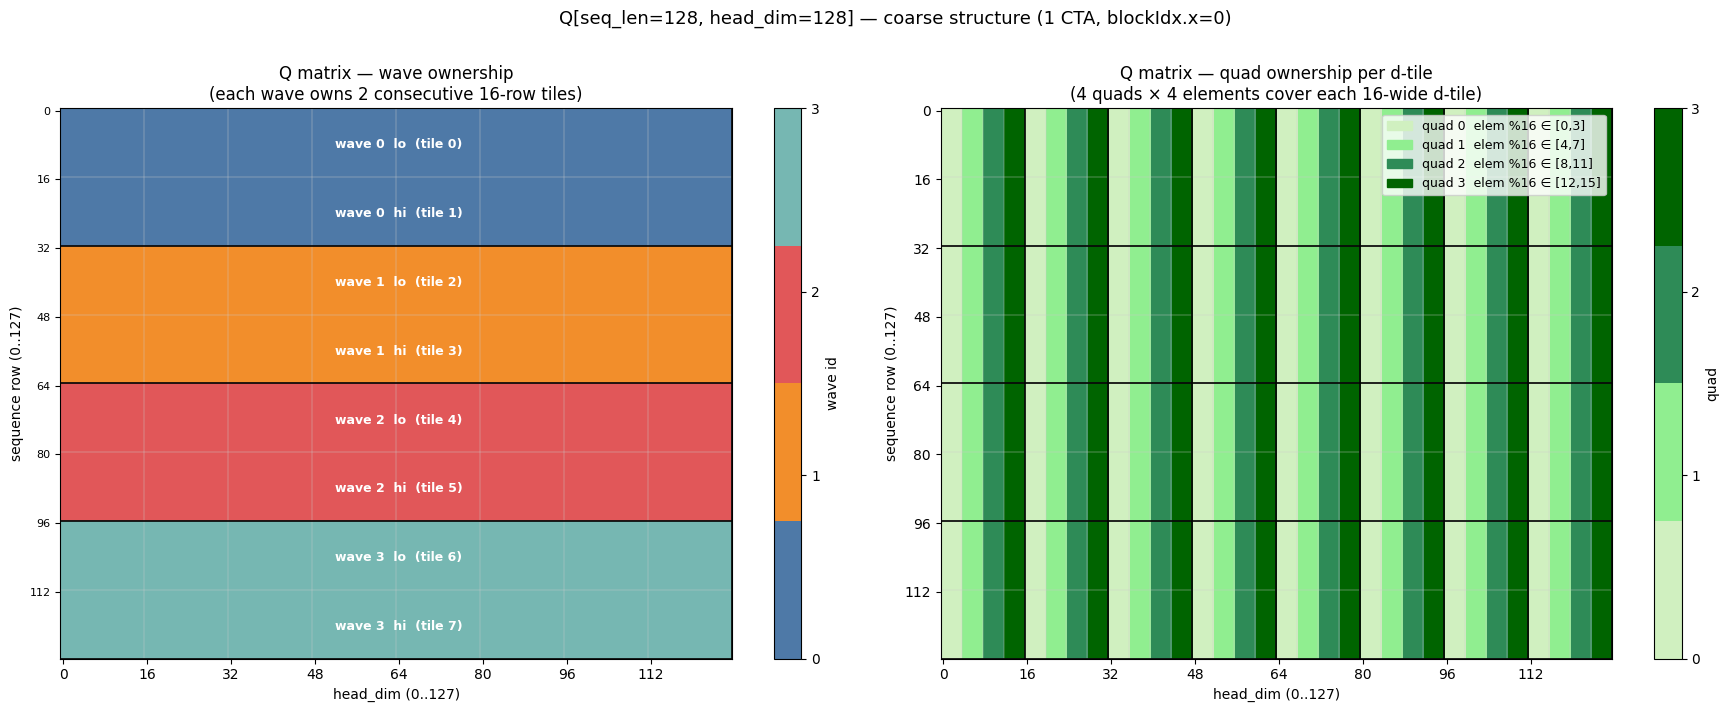

In [2]:
# ── coarse Q view: seq_len=128, blockIdx.x=0 ─────────────────────────────────
seq_len    = 128
q_tiles    = seq_len // kKTile   # 8
blockIdx_x = 0

# For every (seq_row, head_col) cell, compute:
#   wave_id  : which wave (0-3) loads this row
#   qg       : lo (0) or hi (1) tile within the wave
#   quad     : which 4-lane group loads this head_col
Q_wave  = np.zeros((seq_len, kHeadDim), dtype=int)
Q_qg    = np.zeros((seq_len, kHeadDim), dtype=int)
Q_quad  = np.zeros((seq_len, kHeadDim), dtype=int)
Q_lane  = np.zeros((seq_len, kHeadDim), dtype=int)
Q_dtile = np.zeros((seq_len, kHeadDim), dtype=int)

for r in range(seq_len):
    tile_idx = r // kKTile
    # which wave and qg own this tile?
    wid_owner = (tile_idx - blockIdx_x * kNumWaves * 2) // 2
    qg_owner  = tile_idx % 2
    row_in_tile = r % kKTile
    for c in range(kHeadDim):
        d    = c // kKTile           # d-tile index (0..7)
        quad = (c % kKTile) // 4     # quad within d-tile (0..3)
        lane = row_in_tile + quad * kKTile   # lane = col | (quad<<4)
        Q_wave [r, c] = wid_owner
        Q_qg   [r, c] = qg_owner
        Q_quad [r, c] = quad
        Q_lane [r, c] = lane
        Q_dtile[r, c] = d

# ── Figure: coarse wave/qg ownership ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: wave ownership
ax = axes[0]
im = ax.imshow(Q_wave, aspect='auto', cmap=WAVE_CMAP, vmin=0, vmax=3,
               interpolation='nearest')
add_grid(ax, seq_len, kHeadDim, step_r=kKTile, step_c=kKTile,
         major_step_r=kKTile*2, major_step_c=kHeadDim)
ax.set_title('Q matrix — wave ownership\n(each wave owns 2 consecutive 16-row tiles)', fontsize=12)
ax.set_xlabel('head_dim (0..127)')
ax.set_ylabel('sequence row (0..127)')
ax.set_xticks(np.arange(0, kHeadDim, kKTile))
ax.set_yticks(np.arange(0, seq_len, kKTile))
ax.yaxis.set_tick_params(labelsize=8)
# label tiles
for t in range(q_tiles):
    wid_t = t // 2; qg_t = t % 2
    ax.text(kHeadDim//2, t*kKTile + kKTile//2,
            f'wave {wid_t}  {"lo" if qg_t==0 else "hi"}  (tile {t})',
            ha='center', va='center', fontsize=9, color='white', fontweight='bold')
plt.colorbar(im, ax=ax, ticks=[0,1,2,3], label='wave id')

# Right: quad within each d-tile
ax2 = axes[1]
im2 = ax2.imshow(Q_quad, aspect='auto', cmap=QUAD_CMAP, vmin=0, vmax=3,
                 interpolation='nearest')
add_grid(ax2, seq_len, kHeadDim, step_r=kKTile, step_c=4,
         major_step_r=kKTile*2, major_step_c=kKTile)
ax2.set_title('Q matrix — quad ownership per d-tile\n(4 quads × 4 elements cover each 16-wide d-tile)', fontsize=12)
ax2.set_xlabel('head_dim (0..127)')
ax2.set_ylabel('sequence row (0..127)')
ax2.set_xticks(np.arange(0, kHeadDim, kKTile))
ax2.set_yticks(np.arange(0, seq_len, kKTile))
patches = [mpatches.Patch(color=QUAD_CMAP(i/3), label=f'quad {i}  elem %16 ∈ [{i*4},{i*4+3}]') for i in range(4)]
ax2.legend(handles=patches, loc='upper right', fontsize=9)
plt.colorbar(im2, ax=ax2, ticks=[0,1,2,3], label='quad')

fig.suptitle('Q[seq_len=128, head_dim=128] — coarse structure (1 CTA, blockIdx.x=0)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Q — fine view: lane assignment within a single 16×128 tile

For a fixed `(row_in_tile, head_dim_col)`:
```
lane = (row_in_tile)  |  (quad << 4)
     = (row % 16)     +  ((head_dim_col % 16) // 4) * 16
```
Every cell holds a different lane.  The pattern repeats every 16 head_dim columns (one d-tile).

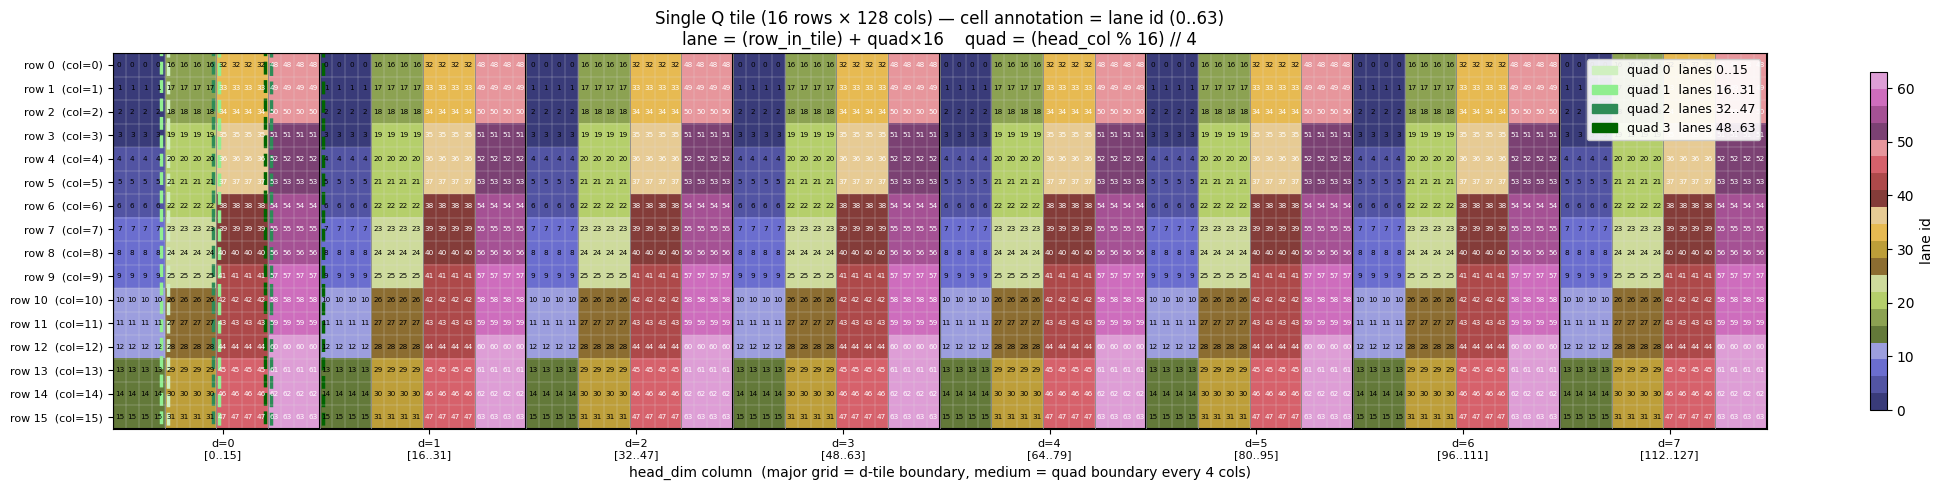

Pattern analysis:
  Each lane owns exactly 1 row × 4 consecutive elems per d-tile = 8 d-tiles × 4 = 32 elems/lane
  64 lanes × 32 elems = 2048 = 16×128 = 2048 ✓ (full tile covered)


In [3]:
# ── Single Q tile (16 rows × 128 cols) annotated with lane numbers ────────────
tile_rows = kKTile   # 16
tile = Q_lane[:kKTile, :]   # tile 0 (wave 0 lo)

fig, ax = plt.subplots(figsize=(22, 5))
im = ax.imshow(tile, aspect='auto', cmap='tab20b', vmin=0, vmax=63,
               interpolation='nearest')

# annotate every cell with lane number
for r in range(tile_rows):
    for c in range(kHeadDim):
        ax.text(c, r, str(tile[r, c]),
                ha='center', va='center', fontsize=5.2,
                color='white' if tile[r,c] > 32 else 'black')

# minor grid: every element; major: every d-tile (16), quad boundary (4)
add_grid(ax, tile_rows, kHeadDim, step_r=1, step_c=1,
         major_step_r=tile_rows, major_step_c=kKTile,
         minor_color='#e0e0e0', major_color='black', lw_minor=0.2, lw_major=1.5)
# quad boundaries within each d-tile (every 4 cols)
for c in range(0, kHeadDim+1, 4):
    ax.axvline(c - 0.5, color='#888888', lw=0.6)

# d-tile labels on top
ax.set_xticks(np.arange(kKTile//2, kHeadDim, kKTile))
ax.set_xticklabels([f'd={d}\n[{d*kKTile}..{d*kKTile+15}]' for d in range(kDTiles)], fontsize=8)
ax.set_yticks(range(tile_rows))
ax.set_yticklabels([f'row {r}  (col={r})' for r in range(tile_rows)], fontsize=8)
ax.set_xlabel('head_dim column  (major grid = d-tile boundary, medium = quad boundary every 4 cols)')
ax.set_title('Single Q tile (16 rows × 128 cols) — cell annotation = lane id (0..63)\n'
             'lane = (row_in_tile) + quad×16    quad = (head_col % 16) // 4', fontsize=12)

# legend: highlight each quad band in d-tile 0
for q in range(4):
    ax.add_patch(mpatches.FancyBboxPatch((q*4 - 0.45, -0.45), 3.9, tile_rows - 0.1,
                  boxstyle='square', facecolor='none',
                  edgecolor=QUAD_CMAP(q/3), lw=2.5, linestyle='--'))
patches = [mpatches.Patch(color=QUAD_CMAP(q/3), label=f'quad {q}  lanes {q*16}..{q*16+15}') for q in range(4)]
ax.legend(handles=patches, loc='upper right', fontsize=9, framealpha=0.9)
plt.colorbar(im, ax=ax, label='lane id', shrink=0.9)
plt.tight_layout()
plt.show()

print('Pattern analysis:')
print(f'  Each lane owns exactly 1 row × 4 consecutive elems per d-tile = {kDTiles} d-tiles × 4 = {kDTiles*4} elems/lane')
print(f'  64 lanes × {kDTiles*4} elems = {64*kDTiles*4} = 16×128 = {kKTile*kHeadDim} ✓ (full tile covered)')

---
# K block — who loads what

K has shape `[seq_len, head_dim]` (row-major bf16).  
All **256 threads** cooperatively load one `[kNBlock=64, kHeadDim=128]` K-block at a time.

```
kvrow = tid >> 2              →  0..63   (one kvrow per group of 4 threads)
kcol  = (tid & 3) * 16        →  0,16,32,48  (16-element head_dim window)
```

K is loaded in **two halves** (`h=0` → head_dim 0..63, `h=1` → 64..127),
each half stored into a separate LDS buffer (`lds_k[0]` and `lds_k[1]`).

---

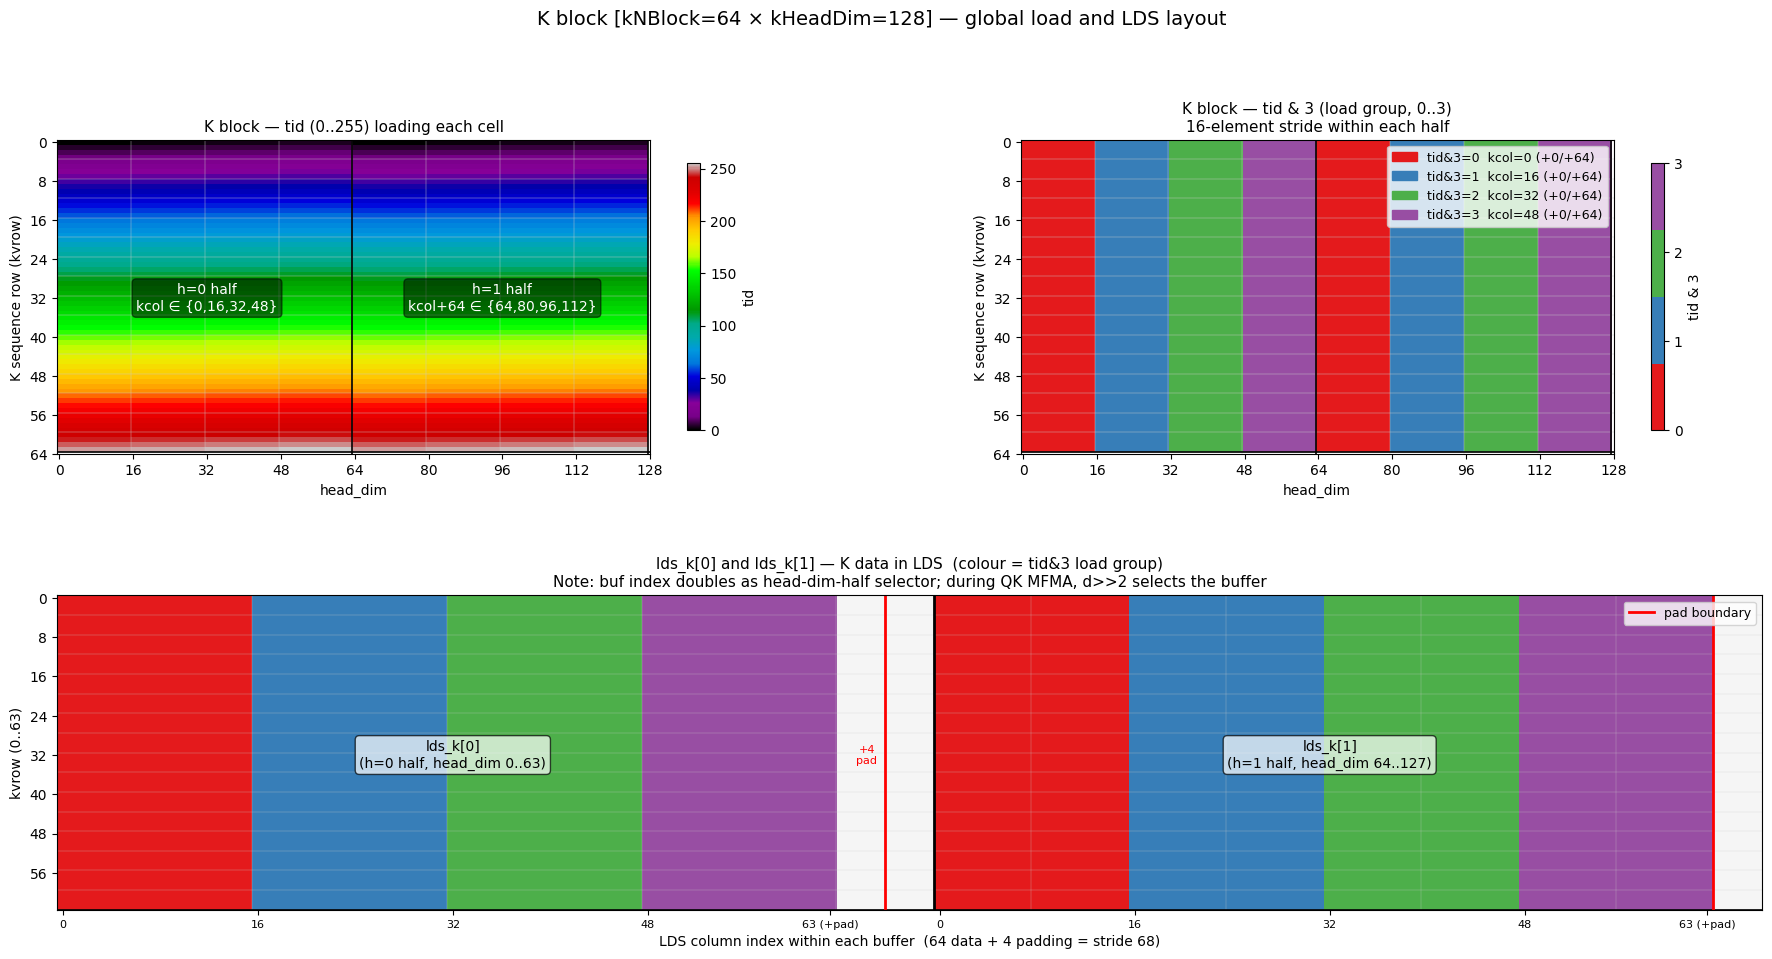

In [4]:
# ── K global block [64, 128]: which thread loads each cell ────────────────────
K_tid    = np.zeros((kNBlock, kHeadDim), dtype=int)
K_kvrow  = np.zeros((kNBlock, kHeadDim), dtype=int)
K_kcol_g = np.zeros((kNBlock, kHeadDim), dtype=int)  # tid & 3
K_half   = np.zeros((kNBlock, kHeadDim), dtype=int)  # 0 or 1

for tid in range(kBlockSize):
    kvrow = tid >> 2
    kcol  = (tid & 3) * 16
    # h=0: cols 0..63;  h=1: cols 64..127
    for h in range(2):
        base = h * kHalfDim + kcol
        for k in range(16):  # each load covers 16 elements
            col = base + k
            if 0 <= col < kHeadDim:
                K_tid   [kvrow, col] = tid
                K_kvrow [kvrow, col] = kvrow
                K_kcol_g[kvrow, col] = tid & 3
                K_half  [kvrow, col] = h

fig = plt.figure(figsize=(22, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── top-left: thread id ───────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
im0 = ax0.imshow(K_tid, aspect='auto', cmap='nipy_spectral', vmin=0, vmax=255,
                 interpolation='nearest')
add_grid(ax0, kNBlock, kHeadDim, step_r=4, step_c=16,
         major_step_r=kNBlock, major_step_c=kHalfDim)
ax0.set_title('K block — tid (0..255) loading each cell', fontsize=11)
ax0.set_xlabel('head_dim'); ax0.set_ylabel('K sequence row (kvrow)')
ax0.set_xticks(np.arange(0, kHeadDim+1, 16))
ax0.set_yticks(np.arange(0, kNBlock+1, 8))
plt.colorbar(im0, ax=ax0, label='tid', shrink=0.85)
# half labels
ax0.text(kHalfDim//2, kNBlock//2, 'h=0 half\nkcol ∈ {0,16,32,48}',
         ha='center', va='center', fontsize=10, color='white',
         bbox=dict(boxstyle='round', fc='black', alpha=0.5))
ax0.text(kHalfDim + kHalfDim//2, kNBlock//2, 'h=1 half\nkcol+64 ∈ {64,80,96,112}',
         ha='center', va='center', fontsize=10, color='white',
         bbox=dict(boxstyle='round', fc='black', alpha=0.5))

# ── top-right: tid & 3 (the 4-thread load group, shows column stride) ─────────
ax1 = fig.add_subplot(gs[0, 1])
im1 = ax1.imshow(K_kcol_g, aspect='auto',
                 cmap=ListedColormap(['#e41a1c','#377eb8','#4daf4a','#984ea3']),
                 vmin=0, vmax=3, interpolation='nearest')
add_grid(ax1, kNBlock, kHeadDim, step_r=4, step_c=16,
         major_step_r=kNBlock, major_step_c=kHalfDim)
ax1.set_title('K block — tid & 3 (load group, 0..3)\n16-element stride within each half', fontsize=11)
ax1.set_xlabel('head_dim'); ax1.set_ylabel('K sequence row (kvrow)')
ax1.set_xticks(np.arange(0, kHeadDim+1, 16))
ax1.set_yticks(np.arange(0, kNBlock+1, 8))
cols4 = ['#e41a1c','#377eb8','#4daf4a','#984ea3']
patches_k = [mpatches.Patch(color=cols4[i], label=f'tid&3={i}  kcol={i*16} (+0/+64)') for i in range(4)]
ax1.legend(handles=patches_k, loc='upper right', fontsize=9)
plt.colorbar(im1, ax=ax1, ticks=[0,1,2,3], label='tid & 3', shrink=0.85)

# ── bottom: lds_k layout — two buffers side by side ───────────────────────────
ax2 = fig.add_subplot(gs[1, :])

# lds_k[buf][kvrow][kcol], stride=68
# buf=0 → h=0 data (head_dim 0..63)  ;  buf=1 → h=1 data (head_dim 64..127)
# Show both buffers stacked side-by-side with a gap.
# In each buffer, colour by tid&3 (shows which 16-element strips each group wrote)
lds_k_view = np.zeros((kNBlock, kLdsStride * 2 + 4), dtype=float)
lds_k_view[:] = -1   # sentinel

for tid in range(kBlockSize):
    kvrow = tid >> 2
    kcol  = (tid & 3) * 16
    grp   = tid & 3
    # buf 0 (h=0): lds_k[0][kvrow][kcol..kcol+15]
    for k in range(16):
        lds_k_view[kvrow, kcol + k] = grp
    # buf 1 (h=1): offset by kLdsStride+4 in our display canvas
    off = kLdsStride + 4
    for k in range(16):
        lds_k_view[kvrow, off + kcol + k] = grp

# mask padding and gap
lds_k_view[:, kHalfDim:kLdsStride] = np.nan      # padding in buf 0
lds_k_view[:, kLdsStride:kLdsStride+4] = np.nan  # gap between buffers
lds_k_view[:, kLdsStride+4+kHalfDim:] = np.nan   # padding in buf 1

cmap_with_nan = ListedColormap(['#e41a1c','#377eb8','#4daf4a','#984ea3'])
cmap_with_nan.set_bad('#f5f5f5')
im2 = ax2.imshow(lds_k_view, aspect='auto', cmap=cmap_with_nan,
                 vmin=0, vmax=3, interpolation='nearest')

# grid
add_grid(ax2, kNBlock, kLdsStride*2+4, step_r=4, step_c=16,
         major_step_r=kNBlock, lw_minor=0.2)
ax2.axvline(kLdsStride - 0.5, color='red', lw=2, label='pad boundary')
ax2.axvline(kLdsStride + 4 - 0.5, color='black', lw=2)
ax2.axvline(kLdsStride + 4 + kHalfDim - 0.5, color='red', lw=2)

# labels
ax2.text(kHalfDim//2, kNBlock//2, 'lds_k[0]\n(h=0 half, head_dim 0..63)',
         ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round', fc='white', alpha=0.7))
ax2.text(kLdsStride+4 + kHalfDim//2, kNBlock//2, 'lds_k[1]\n(h=1 half, head_dim 64..127)',
         ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round', fc='white', alpha=0.7))
ax2.text(kHalfDim + (kLdsStride-kHalfDim)//2, kNBlock//2, '+4\npad',
         ha='center', va='center', fontsize=8, color='red')

ax2.set_xticks([0, 16, 32, 48, 63, kLdsStride+4, kLdsStride+20, kLdsStride+36, kLdsStride+52, kLdsStride+67])
ax2.set_xticklabels(['0','16','32','48','63 (+pad)',
                     '0','16','32','48','63 (+pad)'], fontsize=8)
ax2.set_yticks(np.arange(0, kNBlock, 8))
ax2.set_xlabel('LDS column index within each buffer  (64 data + 4 padding = stride 68)')
ax2.set_ylabel('kvrow (0..63)')
ax2.set_title('lds_k[0] and lds_k[1] — K data in LDS  (colour = tid&3 load group)\n'
              'Note: buf index doubles as head-dim-half selector; '
              'during QK MFMA, d>>2 selects the buffer', fontsize=11)
ax2.legend(loc='upper right', fontsize=9)

fig.suptitle('K block [kNBlock=64 × kHeadDim=128] — global load and LDS layout',
             fontsize=14, y=1.01)
plt.show()

---
# V block — who loads what, and the transpose into LDS

V has the same global shape as K: `[seq_len, head_dim]` (row-major bf16).  
But it is stored into LDS **transposed**, so that during the P×V MFMA,
the KV-row axis becomes the fast (column) axis:

```
lds_v shape: [4 slabs][kKTile=16 rows][kLdsStride=68 cols]
             = [4 × 16 head_dim rows] × [64 KV columns]
```

The 128 head_dim columns map to 4 slabs × 16 rows as follows:

| head_dim range | loaded by | → lds_v slab | half |
|----------------|-----------|--------------|------|
| 0 .. 15 | va0 (vdim=0..7, 8..15) | slab 0 rows 0..15 | V_a |
| 16 .. 31 | va0 (vdim=16..31) | slab 1 rows 0..15 | V_a |
| 32 .. 47 | va1 (vdim=0..15) | slab 2 rows 0..15 | V_a |
| 48 .. 63 | va1 (vdim=16..31) | slab 3 rows 0..15 | V_a |
| 64 .. 79 | vb0 → **reuses slab 0** | slab 0 rows 0..15 | V_b |
| 80 .. 95 | vb0 → **reuses slab 1** | slab 1 rows 0..15 | V_b |
| 96 ..111 | vb1 → **reuses slab 2** | slab 2 rows 0..15 | V_b |
|112 ..127 | vb1 → **reuses slab 3** | slab 3 rows 0..15 | V_b |

lds_v is processed in **two phases** (V_a then V_b) so the 4 slabs can be reused.

---

All V cells covered ✓


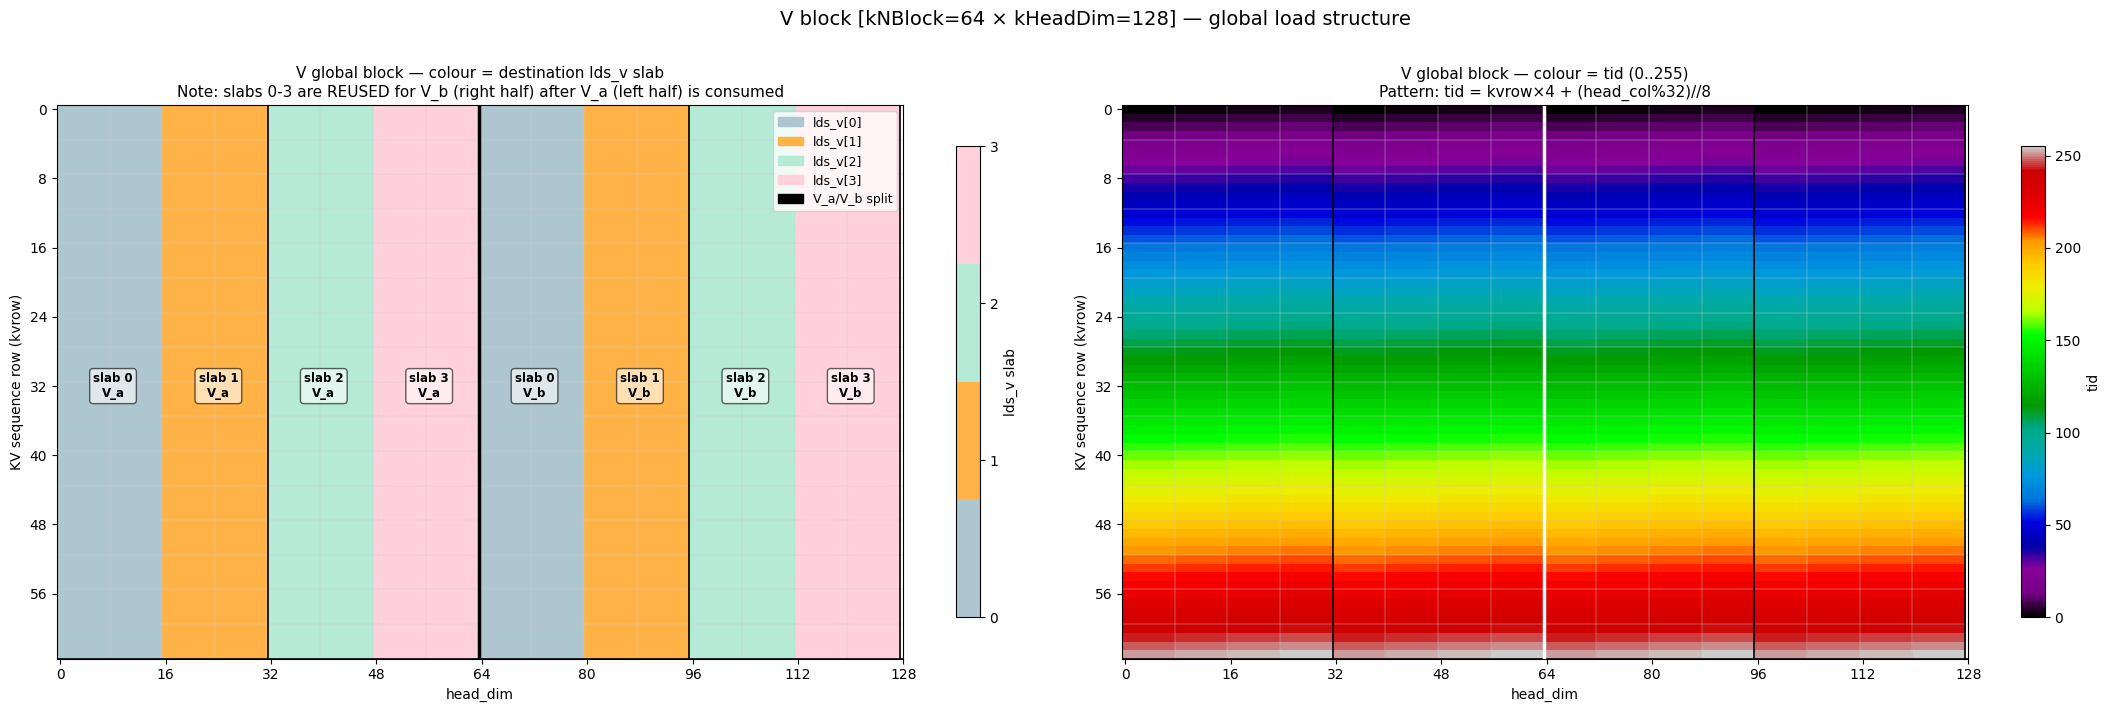

In [5]:
# ── helper: for a given global head_dim position h, compute destination in lds_v
def v_lds_dest(h):
    """Returns (slab, row_in_slab) for V[:, h]."""
    chunk = h // 32          # 0=va0, 1=va1, 2=vb0, 3=vb1
    vdim  = (h % 32) // 8 * 8   # 0, 8, 16, 24
    elem_in_8 = h % 8
    if   chunk == 0: dt, d0 = vdim >> 4,              vdim & 15
    elif chunk == 1: dt, d0 = (32 + vdim) >> 4,       (32 + vdim) & 15
    elif chunk == 2: dt, d0 = ((64 + vdim) >> 4) - 4, (64 + vdim) & 15
    else:            dt, d0 = ((96 + vdim) >> 4) - 4, (96 + vdim) & 15
    return dt, d0 + elem_in_8

# Build maps
V_tid      = np.zeros((kNBlock, kHeadDim), dtype=int)
V_slab     = np.zeros((kNBlock, kHeadDim), dtype=int)   # which lds_v slab
V_row      = np.zeros((kNBlock, kHeadDim), dtype=int)   # row within slab
V_phase    = np.zeros((kNBlock, kHeadDim), dtype=int)   # 0=V_a, 1=V_b

for tid in range(kBlockSize):
    kvrow = tid >> 2
    vdim_t = (tid & 3) * 8   # 0, 8, 16, 24
    # This thread loads V[kvrow, vdim_t], [kvrow, 32+vdim_t],
    #                     [kvrow, 64+vdim_t], [kvrow, 96+vdim_t]  (8 elements each)
    for chunk_base, vphase in [(0, 0), (32, 0), (64, 1), (96, 1)]:
        for i in range(8):
            h = chunk_base + vdim_t + i
            if h < kHeadDim:
                slab, row = v_lds_dest(h)
                V_tid  [kvrow, h] = tid
                V_slab [kvrow, h] = slab
                V_row  [kvrow, h] = row
                V_phase[kvrow, h] = vphase

# Verify every cell is covered
assert (V_tid >= 0).all(), 'some V cell not covered!'
print('All V cells covered ✓')

# ── Figure: V global block ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# Left: colour by lds_v slab destination
ax = axes[0]
im = ax.imshow(V_slab, aspect='auto', cmap=SLAB_CMAP, vmin=0, vmax=3,
               interpolation='nearest')
add_grid(ax, kNBlock, kHeadDim, step_r=4, step_c=8,
         major_step_r=kNBlock, major_step_c=32)
# phase boundary
ax.axvline(kHalfDim - 0.5, color='black', lw=2.5, label='V_a / V_b boundary')
ax.legend(loc='upper right', fontsize=9)
ax.set_title('V global block — colour = destination lds_v slab\n'
             'Note: slabs 0-3 are REUSED for V_b (right half) after V_a (left half) is consumed',
             fontsize=11)
ax.set_xlabel('head_dim'); ax.set_ylabel('KV sequence row (kvrow)')
ax.set_xticks(np.arange(0, kHeadDim+1, 16))
ax.set_yticks(np.arange(0, kNBlock, 8))
# label slabs
for slab in range(4):
    c_va = slab * 16 + 8
    c_vb = kHalfDim + slab * 16 + 8
    for c, lbl in [(c_va, f'slab {slab}\nV_a'), (c_vb, f'slab {slab}\nV_b')]:
        ax.text(c, kNBlock//2, lbl, ha='center', va='center',
                fontsize=8.5, fontweight='bold',
                bbox=dict(boxstyle='round', fc='white', alpha=0.6))
slab_patches = [mpatches.Patch(color=SLAB_CMAP(s/3), label=f'lds_v[{s}]') for s in range(4)]
ax.legend(handles=slab_patches + [mpatches.Patch(color='black', label='V_a/V_b split')],
          loc='upper right', fontsize=9)
plt.colorbar(im, ax=ax, ticks=[0,1,2,3], label='lds_v slab', shrink=0.85)

# Right: colour by tid (thread loading each cell)
ax2 = axes[1]
im2 = ax2.imshow(V_tid, aspect='auto', cmap='nipy_spectral', vmin=0, vmax=255,
                 interpolation='nearest')
add_grid(ax2, kNBlock, kHeadDim, step_r=4, step_c=8,
         major_step_r=kNBlock, major_step_c=32)
ax2.axvline(kHalfDim - 0.5, color='white', lw=2.5)
ax2.set_title('V global block — colour = tid (0..255)\n'
              'Pattern: tid = kvrow×4 + (head_col%32)//8', fontsize=11)
ax2.set_xlabel('head_dim'); ax2.set_ylabel('KV sequence row (kvrow)')
ax2.set_xticks(np.arange(0, kHeadDim+1, 16))
ax2.set_yticks(np.arange(0, kNBlock, 8))
plt.colorbar(im2, ax=ax2, label='tid', shrink=0.85)

fig.suptitle('V block [kNBlock=64 × kHeadDim=128] — global load structure', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## V — transposed LDS layout (lds_v)

After the transpose, `lds_v[slab][head_dim_row][kvrow]` holds `V[kvrow, slab*16 + head_dim_row]`.  
The **column axis** (fast axis) is now **kvrow** — the contraction dimension for P×V MFMA.

Each figure below shows one slab.  Colour = the thread that wrote that cell (= `tid = kvrow×4 + vdim_group`).

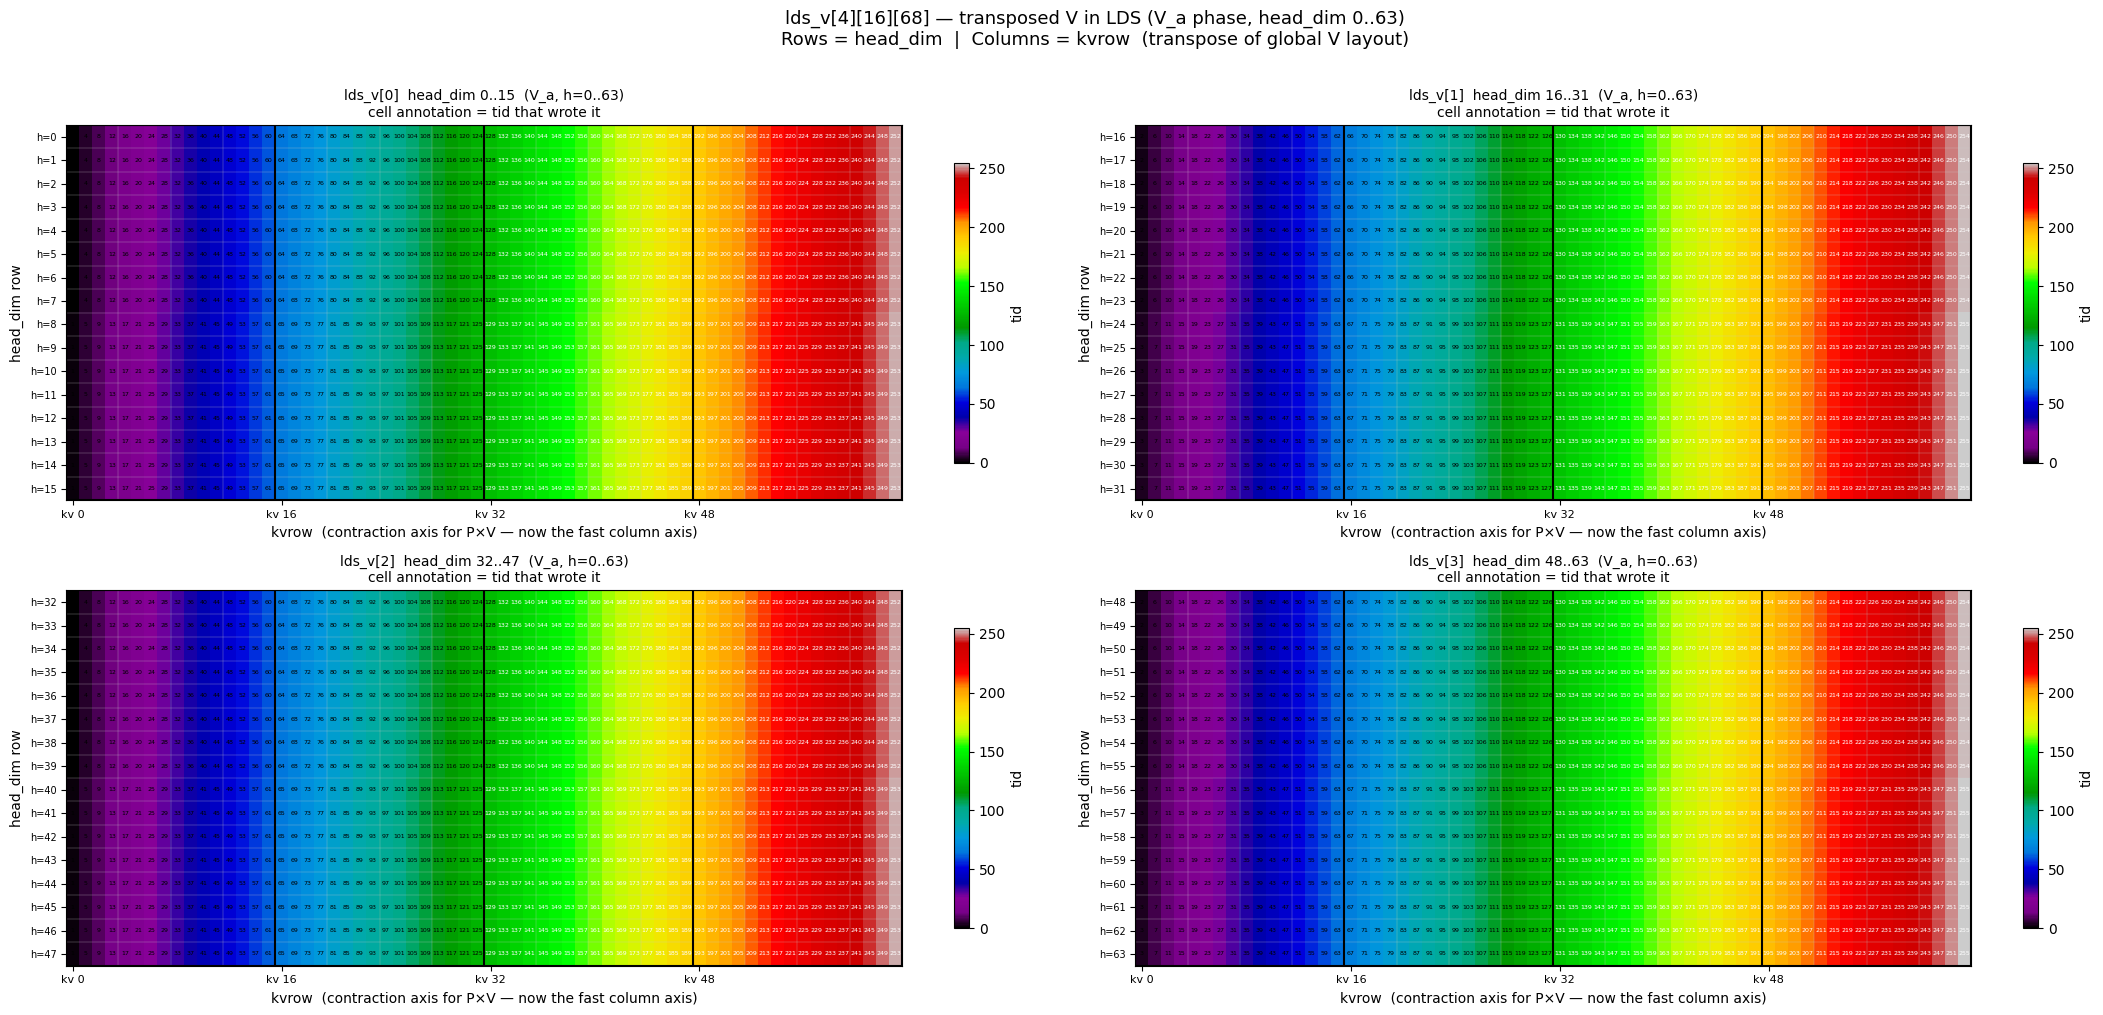

V_a LDS cells covered: 4096 / 4096 = 100.0%  ✓


In [6]:
# ── lds_v[4 slabs][16 rows][68 cols]: who wrote each cell ─────────────────────
# We fill for V_a (slabs as written by va0 + va1 stores)
lds_v_tid = np.full((4, kKTile, kLdsStride), -1, dtype=int)

for tid in range(kBlockSize):
    kvrow  = tid >> 2
    vdim_t = (tid & 3) * 8
    for chunk_base, vphase in [(0, 0), (32, 0)]:   # V_a only (va0, va1)
        for i in range(8):
            h = chunk_base + vdim_t + i
            if h < kHeadDim:
                slab, row = v_lds_dest(h)
                if kvrow < kLdsStride:
                    lds_v_tid[slab, row, kvrow] = tid

fig, axes = plt.subplots(2, 2, figsize=(22, 10))

for slab in range(4):
    ax = axes[slab // 2][slab % 2]
    data = lds_v_tid[slab, :, :kNBlock].astype(float)
    data_masked = np.ma.masked_where(data < 0, data)
    cmap_tid = plt.cm.nipy_spectral
    cmap_tid.set_bad('#dddddd')
    im = ax.imshow(data_masked, aspect='auto', cmap=cmap_tid, vmin=0, vmax=255,
                   interpolation='nearest')

    # annotate each cell with the writing tid
    for r in range(kKTile):
        for c in range(kNBlock):
            v = lds_v_tid[slab, r, c]
            if v >= 0:
                ax.text(c, r, str(v),
                        ha='center', va='center', fontsize=4.5,
                        color='white' if v > 128 else 'black')

    add_grid(ax, kKTile, kNBlock, step_r=1, step_c=4,
             major_step_r=kKTile, major_step_c=kKTile,
             lw_minor=0.2, lw_major=1.5)

    # column labels: every 4 (sub-tile boundary)
    ax.set_xticks(np.arange(0, kNBlock, kKTile))
    ax.set_xticklabels([f'kv {v}' for v in np.arange(0, kNBlock, kKTile)], fontsize=8)
    ax.set_yticks(range(kKTile))
    ax.set_yticklabels([f'h={slab*kKTile+r}' for r in range(kKTile)], fontsize=7)
    ax.set_xlabel('kvrow  (contraction axis for P×V — now the fast column axis)')
    ax.set_ylabel('head_dim row')
    ax.set_title(f'lds_v[{slab}]  head_dim {slab*kKTile}..{slab*kKTile+15}  (V_a, h=0..63)\n'
                 f'cell annotation = tid that wrote it', fontsize=10)
    plt.colorbar(im, ax=ax, label='tid', shrink=0.8)

fig.suptitle('lds_v[4][16][68] — transposed V in LDS (V_a phase, head_dim 0..63)\n'
             'Rows = head_dim  |  Columns = kvrow  (transpose of global V layout)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# sanity check: every cell should be written by exactly one thread
covered = (lds_v_tid[:, :, :kNBlock] >= 0)
print(f'V_a LDS cells covered: {covered.sum()} / {4 * kKTile * kNBlock} = {covered.mean()*100:.1f}%  ✓')

---
# MFMA computation tiles

Now that we know how Q/K/V are laid out in registers and LDS, here is the full
computation picture for **one wave** (which owns 2 Q tiles = 32 Q rows).

## QK → S accumulator

```
S[qg][sn]   fp32x4   shape per lane: (2 qg) × (4 sn) × 4 fp32
```

The full S matrix for one wave: `[32 Q-rows, 64 KV-rows]`

## PV → O accumulator

```
O[qg][t]    fp32x4   shape per lane: (2 qg) × (8 t) × 4 fp32
```

The full O matrix for one wave: `[32 Q-rows, 128 head-dim]`

---

/tmp/ipykernel_3920173/3231747936.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('tab10', 8), vmin=0, vmax=7,
/tmp/ipykernel_3920173/3231747936.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('tab20', 16), vmin=0, vmax=15,


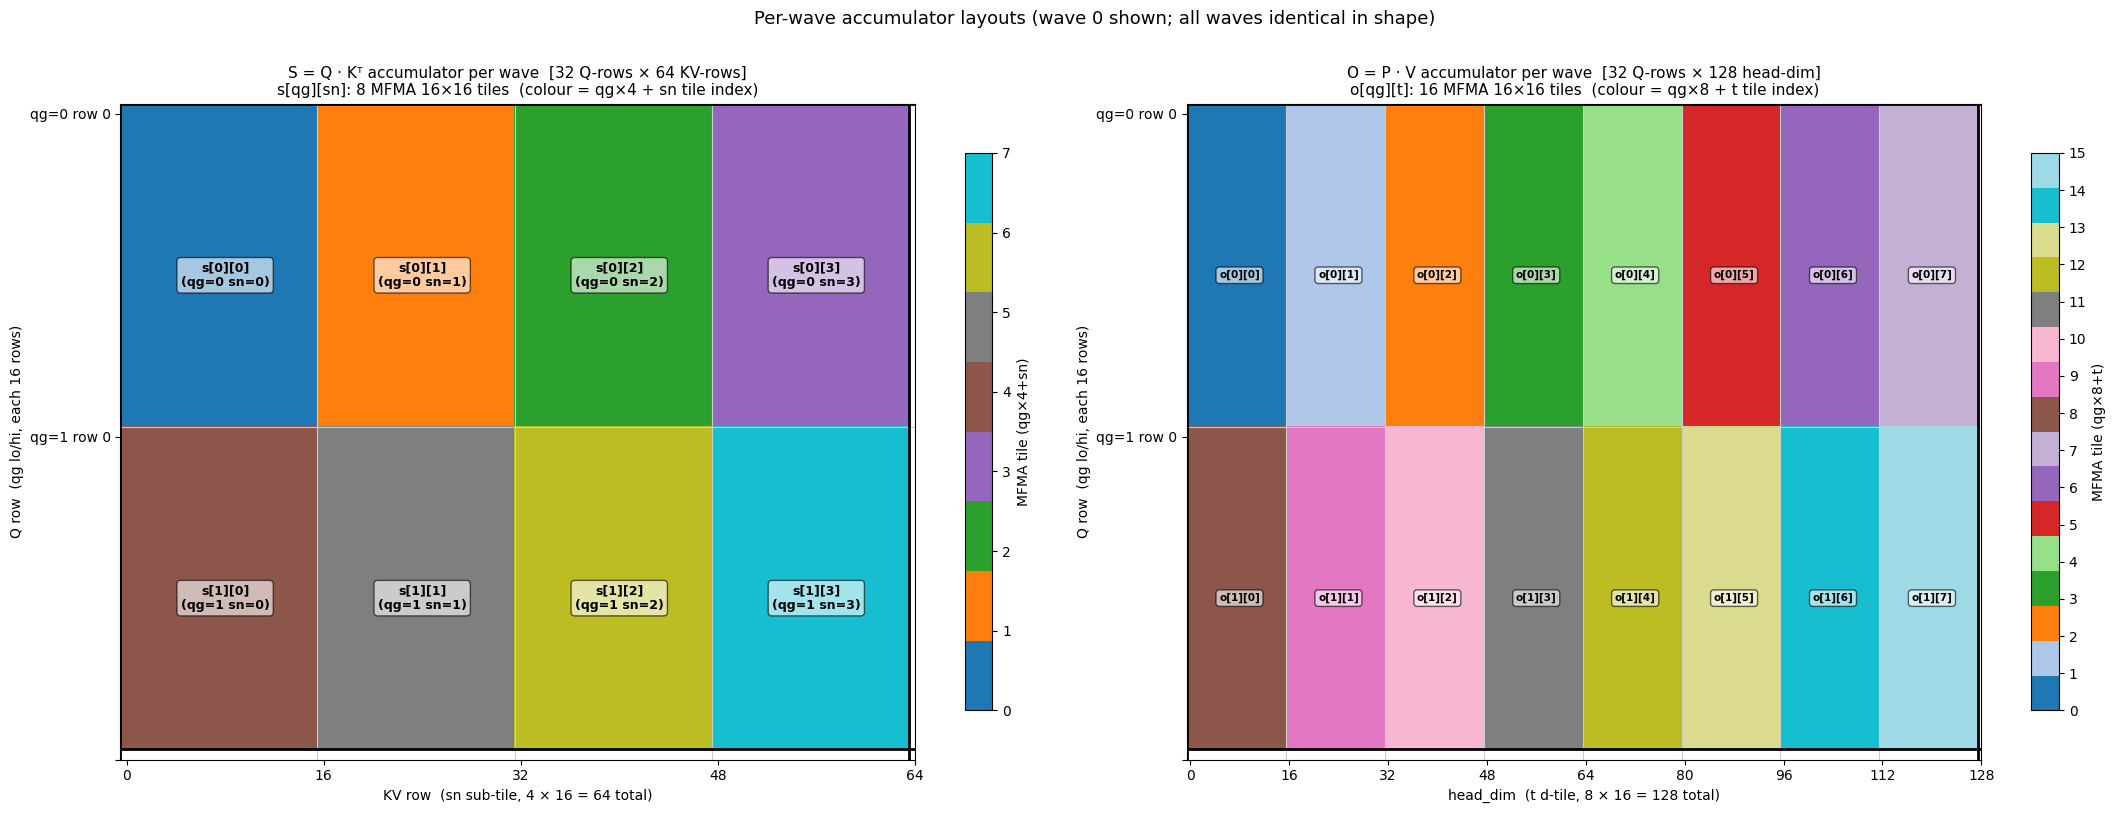

In [7]:
# ── S accumulator: [2 qg, 4 sn] MFMA tiles → [32 Q-rows, 64 KV-rows] ─────────
# Each tile s[qg][sn] is a 16×16 fp32 MFMA result.
# Row axis  = Q rows  (qg selects lo/hi 16-row band, col=lane&15 picks the row)
# Col axis  = KV rows (sn selects 16-row sub-tile, col=lane&15 picks the col)
# Per-lane: 4 fp32 values at (cols 0-3 or 4 positions determined by MFMA D layout)

S_qg = np.zeros((kKTile*2, kNBlock), dtype=int)   # which qg
S_sn = np.zeros((kKTile*2, kNBlock), dtype=int)   # which sn
S_lane = np.zeros((kKTile*2, kNBlock), dtype=int)

for qg in range(2):
    for sn in range(kNSub):
        for lane in range(kWaveSize):
            col_l  = lane & 15
            quad_l = lane >> 4
            # MFMA 16x16x16 D-matrix layout: lane owns rows (col_l) and
            # 4 consecutive output columns at quad_l*4 .. quad_l*4+3
            q_row   = qg * kKTile + col_l
            kv_base = sn * kKTile + quad_l * 4
            for k in range(4):
                S_qg  [q_row, kv_base + k] = qg
                S_sn  [q_row, kv_base + k] = sn
                S_lane[q_row, kv_base + k] = lane

# ── O accumulator: [2 qg, 8 t] MFMA tiles → [32 Q-rows, 128 head-dim] ────────
O_qg   = np.zeros((kKTile*2, kHeadDim), dtype=int)
O_t    = np.zeros((kKTile*2, kHeadDim), dtype=int)
O_lane = np.zeros((kKTile*2, kHeadDim), dtype=int)

for qg in range(2):
    for t in range(kDTiles):
        for lane in range(kWaveSize):
            col_l  = lane & 15
            quad_l = lane >> 4
            q_row   = qg * kKTile + col_l
            hd_base = t * kKTile + quad_l * 4
            for k in range(4):
                O_qg  [q_row, hd_base + k] = qg
                O_t   [q_row, hd_base + k] = t
                O_lane[q_row, hd_base + k] = lane

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# ── Left: S accumulator (Q-rows × KV-rows) ───────────────────────────────────
ax = axes[0]
# colour by (qg*4 + sn) to show the 8 MFMA tile slots
S_tile_id = S_qg * kNSub + S_sn
im = ax.imshow(S_tile_id, aspect='auto',
               cmap=plt.cm.get_cmap('tab10', 8), vmin=0, vmax=7,
               interpolation='nearest')
add_grid(ax, kKTile*2, kNBlock, step_r=kKTile, step_c=kKTile,
         major_step_r=kKTile*2, major_step_c=kNBlock, lw_minor=0.8, lw_major=2)
for qg in range(2):
    for sn in range(kNSub):
        ax.text(sn * kKTile + kKTile//2, qg * kKTile + kKTile//2,
                f's[{qg}][{sn}]\n(qg={qg} sn={sn})',
                ha='center', va='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', fc='white', alpha=0.6))
ax.set_title('S = Q · Kᵀ accumulator per wave  [32 Q-rows × 64 KV-rows]\n'
             's[qg][sn]: 8 MFMA 16×16 tiles  (colour = qg×4 + sn tile index)', fontsize=11)
ax.set_xlabel('KV row  (sn sub-tile, 4 × 16 = 64 total)')
ax.set_ylabel('Q row  (qg lo/hi, each 16 rows)')
ax.set_xticks(np.arange(0, kNBlock+1, kKTile))
ax.set_yticks(np.arange(0, kKTile*2+1, kKTile))
ax.set_yticklabels([f'qg=0 row 0', f'qg=1 row 0', ''])
plt.colorbar(im, ax=ax, ticks=range(8),
             label='MFMA tile (qg×4+sn)', shrink=0.85)

# ── Right: O accumulator (Q-rows × head-dim) ──────────────────────────────────
ax2 = axes[1]
O_tile_id = O_qg * kDTiles + O_t
im2 = ax2.imshow(O_tile_id, aspect='auto',
                 cmap=plt.cm.get_cmap('tab20', 16), vmin=0, vmax=15,
                 interpolation='nearest')
add_grid(ax2, kKTile*2, kHeadDim, step_r=kKTile, step_c=kKTile,
         major_step_r=kKTile*2, major_step_c=kHeadDim, lw_minor=0.8, lw_major=2)
for qg in range(2):
    for t in range(kDTiles):
        ax2.text(t * kKTile + kKTile//2, qg * kKTile + kKTile//2,
                 f'o[{qg}][{t}]',
                 ha='center', va='center', fontsize=7.5, fontweight='bold',
                 bbox=dict(boxstyle='round', fc='white', alpha=0.6))
ax2.set_title('O = P · V accumulator per wave  [32 Q-rows × 128 head-dim]\n'
              'o[qg][t]: 16 MFMA 16×16 tiles  (colour = qg×8 + t tile index)', fontsize=11)
ax2.set_xlabel('head_dim  (t d-tile, 8 × 16 = 128 total)')
ax2.set_ylabel('Q row  (qg lo/hi, each 16 rows)')
ax2.set_xticks(np.arange(0, kHeadDim+1, kKTile))
ax2.set_yticks(np.arange(0, kKTile*2+1, kKTile))
ax2.set_yticklabels([f'qg=0 row 0', f'qg=1 row 0', ''])
plt.colorbar(im2, ax=ax2, ticks=range(16),
             label='MFMA tile (qg×8+t)', shrink=0.85)

fig.suptitle('Per-wave accumulator layouts (wave 0 shown; all waves identical in shape)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
# Lane-level view: which lane owns which output cell

For each accumulator, show the per-lane ownership at the finest granularity.

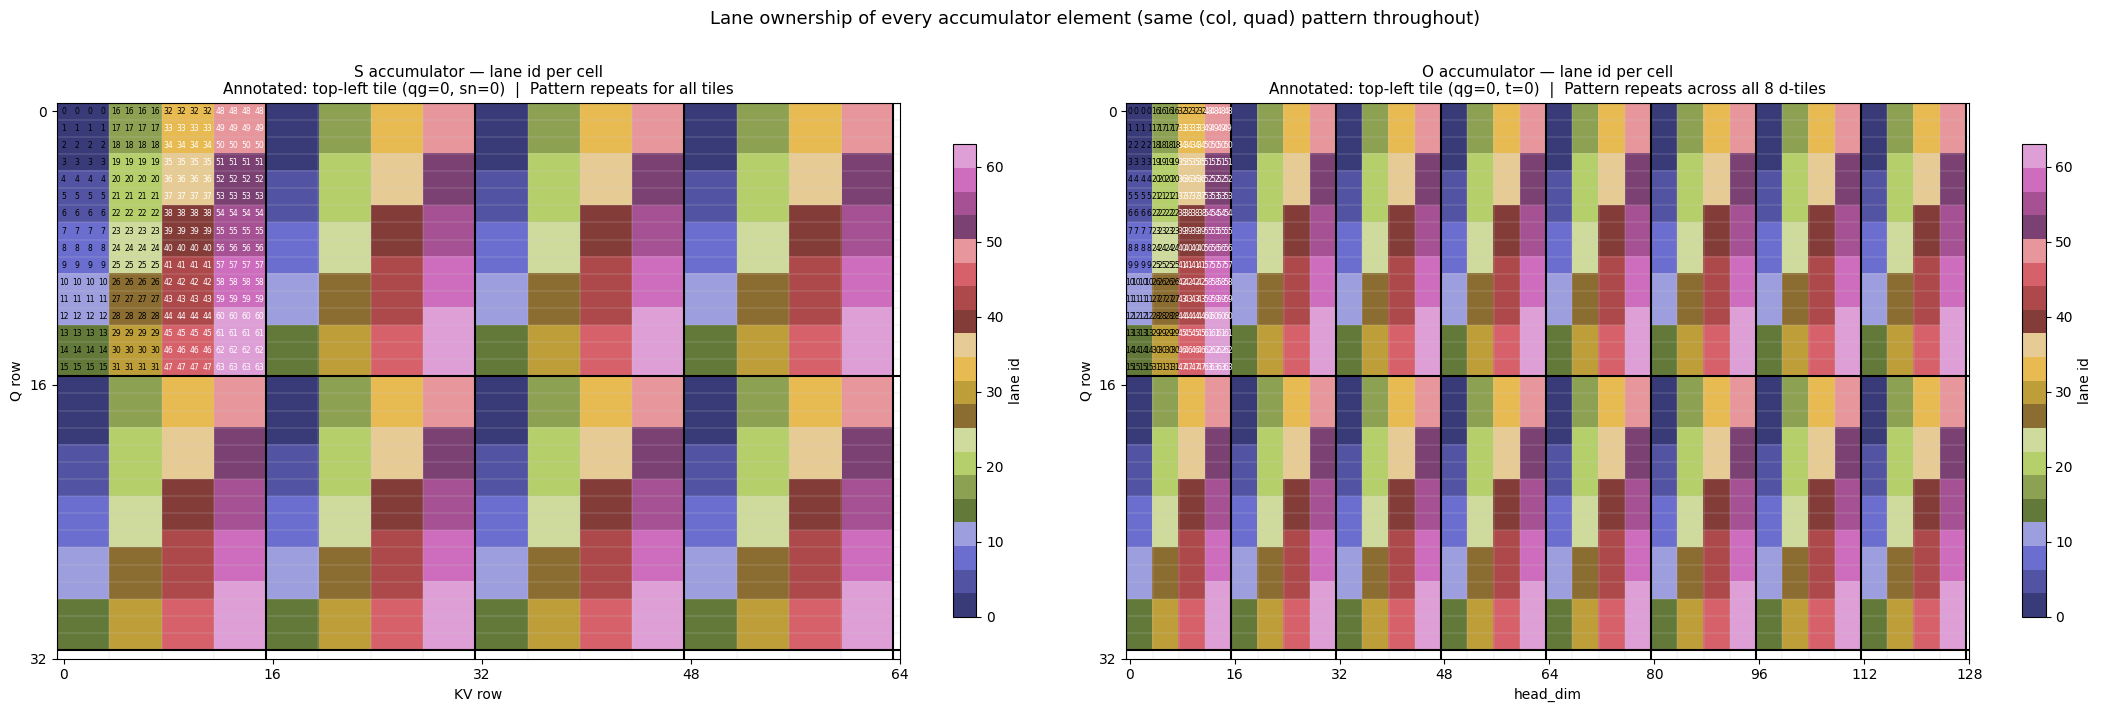

Q-load lane map == O-store lane map  ✓  (perfectly symmetric read/write)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# ── S lane map ────────────────────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(S_lane, aspect='auto', cmap='tab20b', vmin=0, vmax=63,
               interpolation='nearest')
add_grid(ax, kKTile*2, kNBlock, step_r=1, step_c=4,
         major_step_r=kKTile, major_step_c=kKTile, lw_minor=0.2, lw_major=1.5)
# annotate first tile (qg=0, sn=0) with lane numbers
for r in range(kKTile):
    for c in range(kKTile):
        ax.text(c, r, str(S_lane[r,c]),
                ha='center', va='center', fontsize=5.5,
                color='white' if S_lane[r,c] > 32 else 'black')
ax.set_title('S accumulator — lane id per cell\n'
             'Annotated: top-left tile (qg=0, sn=0)  |  Pattern repeats for all tiles', fontsize=11)
ax.set_xlabel('KV row'); ax.set_ylabel('Q row')
ax.set_xticks(np.arange(0, kNBlock+1, kKTile))
ax.set_yticks(np.arange(0, kKTile*2+1, kKTile))
plt.colorbar(im, ax=ax, label='lane id', shrink=0.85)

# ── O lane map ────────────────────────────────────────────────────────────────
ax2 = axes[1]
im2 = ax2.imshow(O_lane, aspect='auto', cmap='tab20b', vmin=0, vmax=63,
                 interpolation='nearest')
add_grid(ax2, kKTile*2, kHeadDim, step_r=1, step_c=4,
         major_step_r=kKTile, major_step_c=kKTile, lw_minor=0.2, lw_major=1.5)
# annotate first tile
for r in range(kKTile):
    for c in range(kKTile):
        ax2.text(c, r, str(O_lane[r,c]),
                 ha='center', va='center', fontsize=5.5,
                 color='white' if O_lane[r,c] > 32 else 'black')
ax2.set_title('O accumulator — lane id per cell\n'
              'Annotated: top-left tile (qg=0, t=0)  |  Pattern repeats across all 8 d-tiles', fontsize=11)
ax2.set_xlabel('head_dim'); ax2.set_ylabel('Q row')
ax2.set_xticks(np.arange(0, kHeadDim+1, kKTile))
ax2.set_yticks(np.arange(0, kKTile*2+1, kKTile))
plt.colorbar(im2, ax=ax2, label='lane id', shrink=0.85)

fig.suptitle('Lane ownership of every accumulator element (same (col, quad) pattern throughout)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── verify Q-load and O-store use the same lane layout ────────────────────────
assert np.array_equal(Q_lane[:kKTile*2, :], O_lane), \
    'Q load and O store lane maps differ!'
print('Q-load lane map == O-store lane map  ✓  (perfectly symmetric read/write)')

---
# Full data-flow summary

One-page overview connecting all the above.

/tmp/ipykernel_3920173/138763567.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  (S_tile_id, plt.cm.get_cmap('tab10',8),  'MFMA tile',  0, 7,  'KV row', 'Q row',
/tmp/ipykernel_3920173/138763567.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  (O_tile_id, plt.cm.get_cmap('tab20',16), 'MFMA tile',  0, 15, 'head_dim', 'Q row',


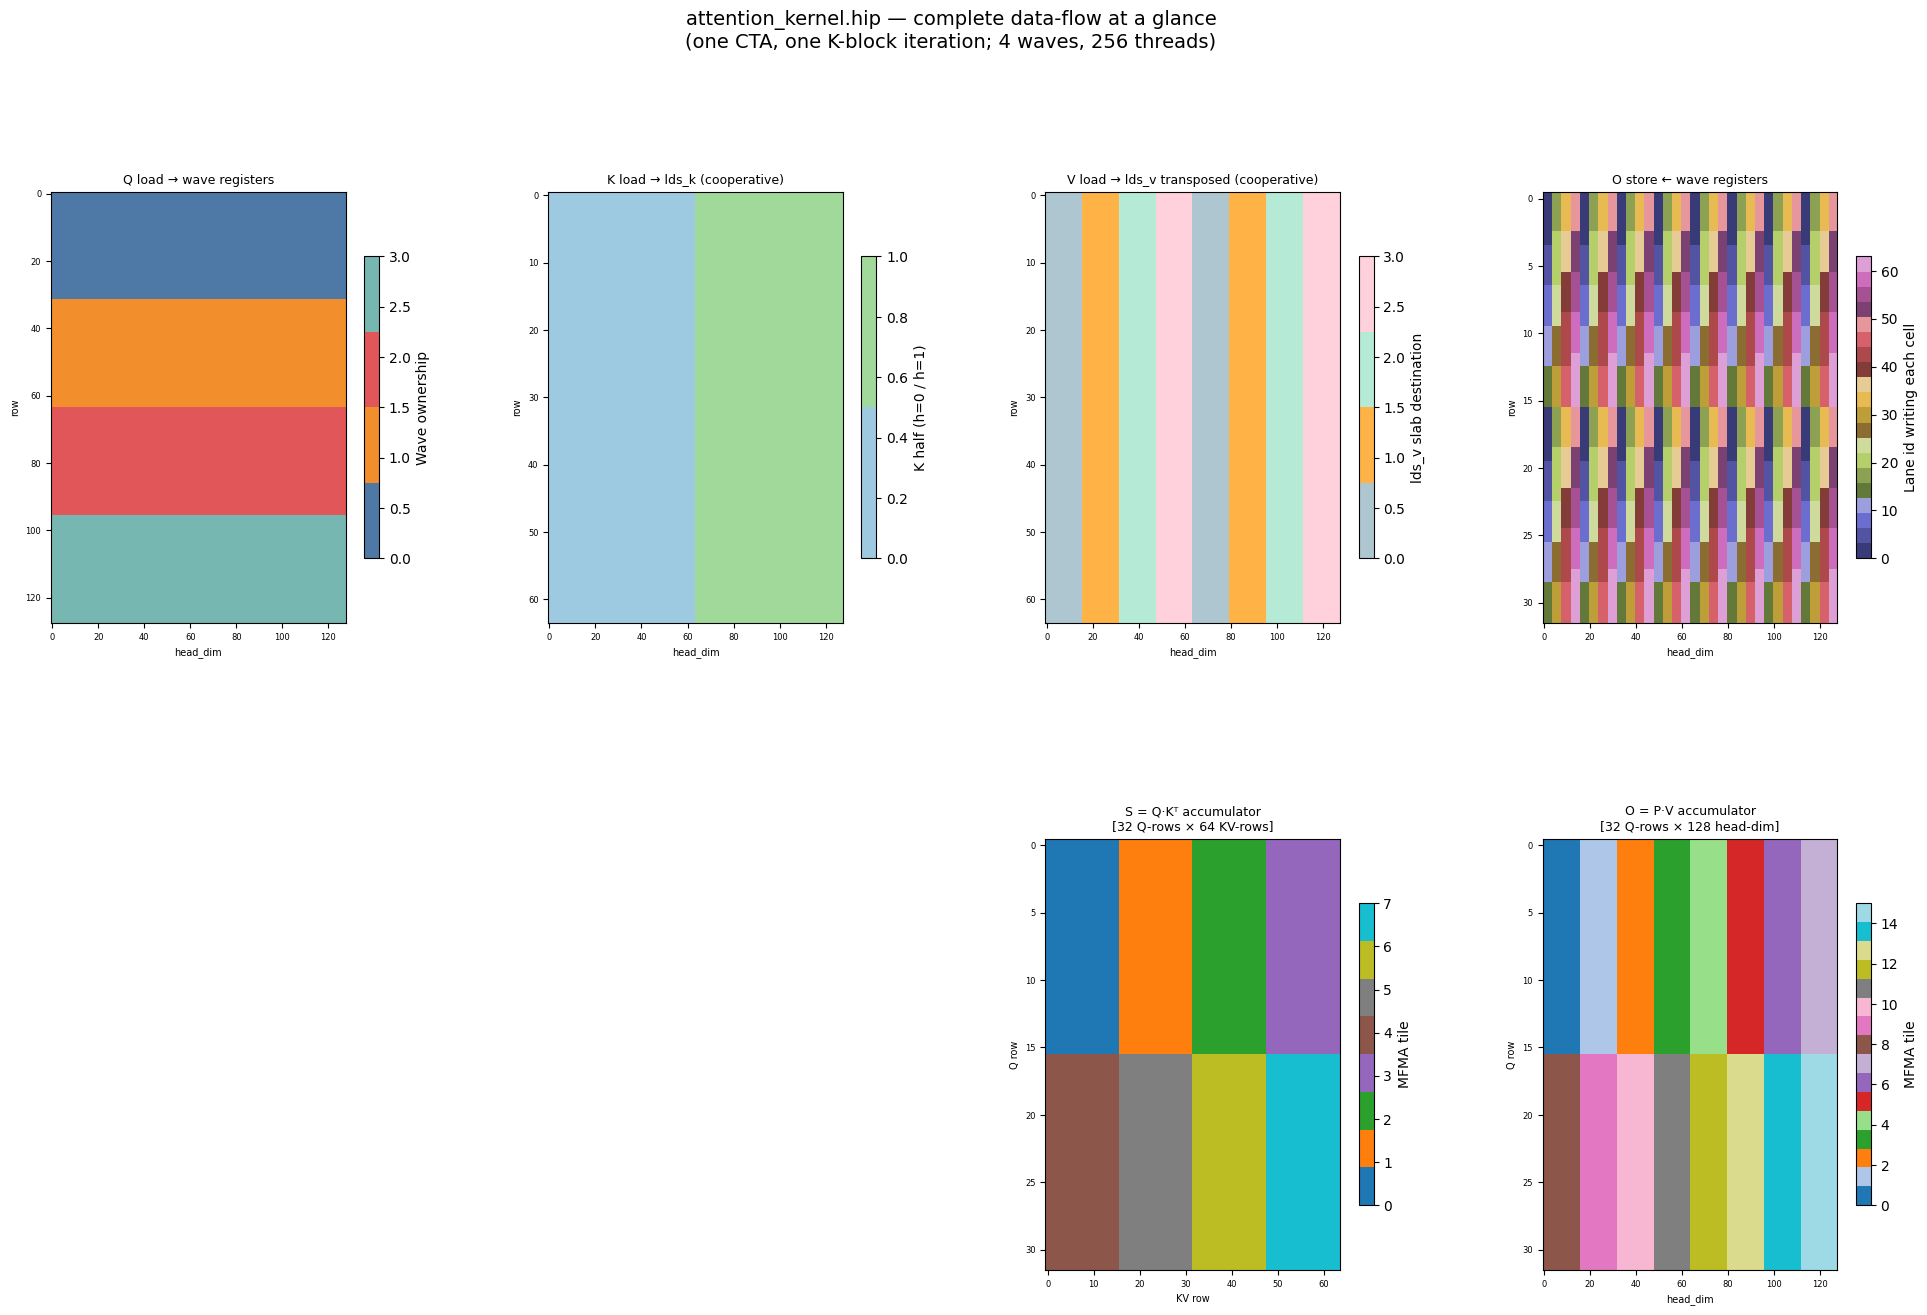

In [9]:
fig = plt.figure(figsize=(24, 14))
gs  = GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.35)

TITLES = [
    ('Q global\n[seq_len × 128]', Q_wave,  WAVE_CMAP,  0, 3),
    ('K global\n[64 × 128]',      K_half,  HALF_CMAP,  0, 1),
    ('V global\n[64 × 128]',      V_slab,  SLAB_CMAP,  0, 3),
    ('O global\n[seq_len × 128]', Q_wave,  WAVE_CMAP,  0, 3),  # same lane map as Q
]

matrices = [
    (Q_wave[:seq_len, :],  WAVE_CMAP,  'Wave ownership',           0, 3),
    (K_half,               HALF_CMAP,  'K half (h=0 / h=1)',       0, 1),
    (V_slab,               SLAB_CMAP,  'lds_v slab destination',   0, 3),
    (O_lane,               'tab20b',   'Lane id writing each cell', 0, 63),
]

row_labels = ['Q load → wave registers',
              'K load → lds_k (cooperative)',
              'V load → lds_v transposed (cooperative)',
              'O store ← wave registers']

for idx, ((data, cmap, clbl, vmin, vmax), rlbl) in enumerate(zip(matrices, row_labels)):
    row, col = idx // 4, idx % 4
    ax = fig.add_subplot(gs[row, col])
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest')
    ax.set_title(rlbl, fontsize=9)
    ax.set_xlabel('head_dim', fontsize=7)
    ax.set_ylabel('row', fontsize=7)
    ax.tick_params(labelsize=6)
    plt.colorbar(im, ax=ax, label=clbl, shrink=0.7)

# Add the two accumulator maps in the second row
for idx2, (data, cmap, clbl, vmin, vmax, xlabel, ylabel, title) in enumerate([
    (S_tile_id, plt.cm.get_cmap('tab10',8),  'MFMA tile',  0, 7,  'KV row', 'Q row',
     'S = Q·Kᵀ accumulator\n[32 Q-rows × 64 KV-rows]'),
    (O_tile_id, plt.cm.get_cmap('tab20',16), 'MFMA tile',  0, 15, 'head_dim', 'Q row',
     'O = P·V accumulator\n[32 Q-rows × 128 head-dim]'),
]):
    ax = fig.add_subplot(gs[1, idx2 + 2])
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_ylabel(ylabel, fontsize=7)
    ax.tick_params(labelsize=6)
    plt.colorbar(im, ax=ax, label=clbl, shrink=0.7)

fig.suptitle('attention_kernel.hip — complete data-flow at a glance\n'
             '(one CTA, one K-block iteration; 4 waves, 256 threads)',
             fontsize=14, y=1.01)
plt.show()